# SmartSwipe — Assignment 1

**Dataset:** `transactions.csv`  
Explore the dataset on your own, find out about the different columns in the dataset.

---


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## Q1 — Python Fundamentals `[10 pts]`

You are given the list `amounts` below.

1. Write a function `summarise(amounts, threshold)` that returns a **dict** with keys:
   - `above_threshold`: list of values strictly greater than `threshold`, sorted descending
   - `mean`: arithmetic mean (no libraries)
   - `count_above`: integer count
2. Call it with `threshold=500` and print the result.


In [23]:
df_transactions=pd.read_csv("/content/sample_data/transactions.csv")

In [28]:
amounts = df_transactions['amount'].tolist()

def summarise(amounts, threshold):
    above_threshold = sorted([a for a in amounts if a > threshold], reverse=True)
    mean = sum(amounts) / len(amounts)
    count_above = len(above_threshold)

    return {
        'above_threshold': above_threshold,
        'mean': mean,
        'count_above': count_above
    }

# Call the function with threshold=500 and print the result
result = summarise(amounts, threshold=500)
print(result)

{'above_threshold': [14205.88, 14011.64, 13184.18, 13086.34, 12304.94, 12250.73, 12199.01, 11818.92, 11772.79, 11662.54, 11471.08, 11371.61, 11234.88, 11199.06, 11195.5, 11101.87, 11073.38, 11069.15, 11007.74, 10905.49, 10864.93, 10713.45, 10491.16, 10380.89, 10359.9, 10312.18, 10252.55, 10151.58, 10150.55, 10095.57, 9796.81, 9794.37, 9783.26, 9764.67, 9716.4, 9612.35, 9608.31, 9600.26, 9593.46, 9568.04, 9492.12, 9468.63, 9421.41, 9420.5, 9416.27, 9376.75, 9323.98, 9311.32, 9244.25, 9211.58, 9126.68, 9093.21, 9051.72, 9026.74, 9016.71, 8991.0, 8891.44, 8880.77, 8858.52, 8828.05, 8807.32, 8786.62, 8769.03, 8713.76, 8698.26, 8687.37, 8678.88, 8671.19, 8657.93, 8651.19, 8649.46, 8643.98, 8628.76, 8604.56, 8600.0, 8591.48, 8535.93, 8504.49, 8465.53, 8427.74, 8426.91, 8375.23, 8358.33, 8317.36, 8290.01, 8255.59, 8217.94, 8211.15, 8191.41, 8187.97, 8173.21, 8154.55, 8151.36, 8089.08, 8081.51, 8077.92, 8054.42, 8021.97, 8015.36, 8010.49, 7982.2, 7973.71, 7950.58, 7946.57, 7941.33, 7901.92, 78

---
## Q2 — NumPy `[15 pts]`

Load **only** the `amount` column into a NumPy array. Then:

1. Print mean, median, std, 10th and 90th percentiles.
2. Create a boolean mask for **outlier** transactions: those where `|amount − mean| > 2 × std`.
3. Normalise the array to `[0, 1]` using min-max scaling and store it as `amounts_norm`.
4. Using `np.histogram`, compute a 10-bin histogram of `amounts_norm` and print bin edges + counts (no plot needed).


In [33]:

ar_amounts = np.array(amounts)

mean = np.mean(ar_amounts)
median = np.median(ar_amounts)
std_amount = np.std(ar_amounts)
percentile_10 = np.percentile(ar_amounts, 10)
percentile_90 = np.percentile(ar_amounts, 90)

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"10th Percentile: {percentile_10:.2f}")
print(f"90th Percentile: {percentile_90:.2f}")

#Boolean definer ..

outlr_trans = np.abs(ar_amounts - mean) > (2 * std_amount)
print(f"Number of outliers: {np.sum(outlr_trans)}")

#max,min and amounts norm

min = np.min(ar_amounts)
max = np.max(ar_amounts)
amounts_norm = (ar_amounts - min) / (max - min)

#10 bin histogram .

hist_counts, hist_bins = np.histogram(amounts_norm, bins=10)

print("\n10-bin Histogram of Normalized Amounts:")
print(f"{hist_bins} + {hist_counts}")

Mean: 1253.02
Median: 433.38
Standard Deviation: 1989.76
10th Percentile: 88.25
90th Percentile: 4024.01
Number of outliers: 353

10-bin Histogram of Normalized Amounts:
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ] + [4020  479  191  187  141   81   47   18    8    4]


---
## Q3 — Pandas: Load & Explore `[15 pts]`

1. Load `smartswipe_transactions.csv` into a DataFrame `df`.
2. Print shape, dtypes, and count of missing values per column.
3. Parse `date` as `datetime` (in-place). Add a column `month` (integer, 1–12).
4. Print the statistical summary for numeric columns only.
5. How many unique `city` and `category` values exist? Print them.


In [46]:
import pandas as pd
df = pd.read_csv('/content/sample_data/transactions.csv')

# Print shape, dtypes, and count of missing values
print(" Shape:", df.shape)
print("\ndtypes:", df.dtypes)
print("\nMissing values per column:", df.isnull().sum())

 Shape: (5176, 9)

dtypes: txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object

Missing values per column: txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64


In [52]:
#3.
df['date'] = pd.to_datetime(df['datetime'])

df['month'] = df['datetime'].dt.month

# 4.  statistical summary
print("\nStatistical Summary for Numeric Columns:\n", df.describe())

# 5. unique `city` and `category` values
print("\nUnique cities and their counts:\n", df['city'].value_counts())
print("\nUnique categories and their counts:\n", df['category'].value_counts())


Statistical Summary for Numeric Columns:
              amount                       datetime     cashback        month  \
count   5176.000000                           5176  4918.000000  5176.000000   
mean    1253.022884  2024-03-30 18:06:04.610703360    29.513211     3.455564   
min       10.000000            2024-01-01 03:29:50     0.000000     1.000000   
25%      173.882500     2024-02-16 03:28:55.500000     1.070000     2.000000   
50%      433.385000     2024-03-30 01:10:56.500000     6.565000     3.000000   
75%     1251.317500  2024-05-14 02:21:02.750000128    21.355000     5.000000   
max    14205.880000            2024-06-29 22:44:09  2440.530000     6.000000   
std     1989.949158                            NaN    87.547840     1.678726   

                                date  
count                           5176  
mean   2024-03-30 18:06:04.610703360  
min              2024-01-01 03:29:50  
25%       2024-02-16 03:28:55.500000  
50%       2024-03-30 01:10:56.500000  
75

---
## Q4 — Pandas: Filter & Transform `[20 pts]`

1. Filter to **approved** transactions only. What fraction of total transactions is this? Print as a percentage.
2. Add column `cashback_rate` = `cashback / amount`. Flag rows where this exceeds 0.10 as `suspicious` (boolean column).
3. Fill any missing `cashback` values with the **per-category median** cashback (do not use a global fill).
4. Create a `spend_tier` column: `low` (amount < 500), `mid` (500–2000), `high` (> 2000).
   Use `pd.cut` — do not write if-else chains.


In [59]:

    # 1. approved transactions and their fraction as percentile
    approved_transactions = df[df['status'] == 'approved']
    approved_fraction = len(approved_transactions) / len(df)
    print(f"Fraction of approved transactions: {approved_fraction:.2%}")

    # 2. defining cashback rates and creating flags using a for loop and if-else
    cashback_rates = []
    suspicious = []
    for index, row in df.iterrows():
        rate = row['cashback'] / row['amount']
        cashback_rates.append(rate)
        if rate > 0.10:
            suspicious.append(True)
        else:
            suspicious.append(False)

    df['cashback_rate'] = cashback_rates
    df['suspicious'] = suspicious
    print("\nNumber of suspicious transactions:", df['suspicious'].sum())

    # 3. Filling missing values by median of that category
    category_medians = df.groupby('category')['cashback'].median()

    def fill_missing(row):
        if pd.isnull(row['cashback']):
            return category_medians.loc[row['category']]
        else:
            return row['cashback']

    df['cashback'] = df.apply(fill_missing, axis=1)
    print("\nMissing values in cashback after filling:", df['cashback'].isnull().sum())

    # 4. spend_tier column:
    def assign_spend_tier(amount):
        if amount < 500:
            return 'low'
        elif 500 <= amount <= 2000:
            return 'mid'
        else:
            return 'high'

    df['spend_tier'] = df['amount'].apply(assign_spend_tier)
    print("\nSpend tier distribution:", df['spend_tier'].value_counts())
    display(df.head())

Fraction of approved transactions: 88.97%

Number of suspicious transactions: 202

Missing values in cashback after filling: 0

Spend tier distribution: spend_tier
low     2784
mid     1519
high     873
Name: count, dtype: int64


,txn_id,user_id,merchant,category,amount,datetime,city,cashback,status,month,date,cashback_rate,suspicious,spend_tier
0,TXN000001,USR0317,Nykaa,Shopping,1152.59,2024-01-01 03:29:50,Delhi,28.820,approved,1,2024-01-01 03:29:50,0.025005,False,mid
1,TXN000002,USR0330,Apollo Pharmacy,Healthcare,10.00,2024-01-01 04:57:03,Hyderabad,0.270,approved,1,2024-01-01 04:57:03,0.027000,False,low
2,TXN000003,USR0096,Jio,Utilities,926.70,2024-01-01 04:57:19,Delhi,10.230,approved,1,2024-01-01 04:57:19,0.011039,False,mid
3,TXN000004,USR0211,Zepto,Groceries,137.71,2024-01-01 05:33:40,Chennai,3.260,approved,1,2024-01-01 05:33:40,0.023673,False,low
4,TXN000005,USR0373,IndiGo,Travel,7001.18,2024-01-01 06:29:07,Delhi,97.165,approved,1,2024-01-01 06:29:07,0.013878,False,high


---
## Q5 — Pandas: Aggregation `[20 pts]`

1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
   Store as a clean DataFrame `category_stats` and print it sorted by total spend descending.
2. Find the **top-3 merchants** by total spend within each city. Output should be a DataFrame with columns `city`, `merchant`, `total_spend`.
3. Build a **month × category pivot table** of average transaction amounts. Print it.


In [ ]:
 # 1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
    category_data = {}
    for index, row in df.iterrows():
        category = row['category']
        amount = row['amount']
        status = row['status']

        if category not in category_data:
            category_data[category] = {
                'total_spend': 0.0,
                'transaction_count': 0,
                'total_declined': 0,
                'amounts': []
            }
        category_data[category]['total_spend'] += amount
        category_data[category]['transaction_count'] += 1
        if status == 'declined':
            category_data[category]['total_declined'] += 1
        category_data[category]['amounts'].append(amount)

    # Calculate final stats and convert to DataFrame
    category_stats_list = []
    for category, data in category_data.items():
        total_spend = data['total_spend']
        transaction_count = data['transaction_count']
        total_declined = data['total_declined']
        avg_transaction_size = total_spend / transaction_count if transaction_count > 0 else 0
        decline_rate = total_declined / transaction_count if transaction_count > 0 else 0

        category_stats_list.append({
            'category': category,
            'total_spend': total_spend,
            'transaction_count': transaction_count,
            'avg_transaction_size': avg_transaction_size,
            'decline_rate': decline_rate
        })

    category_stats = pd.DataFrame(category_stats_list)
    category_stats = category_stats.sort_values(by='total_spend', ascending=False).set_index('category')
    print("\nCategory Statistics (sorted by total spend descending):\n", category_stats)

    # 2. Find the **top-3 merchants** by total spend within each city.
    city_merchant_spend = {}
    for index, row in df.iterrows():
        city = row['city']
        merchant = row['merchant']
        amount = row['amount']

        if city not in city_merchant_spend:
            city_merchant_spend[city] = {}
        if merchant not in city_merchant_spend[city]:
            city_merchant_spend[city][merchant] = 0.0
        city_merchant_spend[city][merchant] += amount

    top_merchants_list = []
    for city, merchants in city_merchant_spend.items():
        sorted_merchants = sorted(merchants.items(), key=lambda item: item[1], reverse=True)
        for merchant, total_spend in sorted_merchants[:3]: # Take top 3
            top_merchants_list.append({'city': city, 'merchant': merchant, 'total_spend': total_spend})

    top_3_merchants = pd.DataFrame(top_merchants_list)
    print("\nTop 3 Merchants by Total Spend within Each City:\n", top_3_merchants)

    # 3. Build a **month × category pivot table** of average transaction amounts.
    month_category_amounts = {}
    for index, row in df.iterrows():
        month = row['month']
        category = row['category']
        amount = row['amount']

        if (month, category) not in month_category_amounts:
            month_category_amounts[(month, category)] = []
        month_category_amounts[(month, category)].append(amount)

    # Calculate averages
    pivot_data = []
    for (month, category), amounts_list in month_category_amounts.items():
        avg_amount = sum(amounts_list) / len(amounts_list)
        pivot_data.append({'month': month, 'category': category, 'avg_amount': avg_amount})

    pivot_df = pd.DataFrame(pivot_data)
    pivot_table_avg_amount = pivot_df.pivot_table(values='avg_amount', index='month', columns='category')
    print("\nMonth x Category Pivot Table (Average Transaction Amounts):\n", pivot_table_avg_amount)

---
## Q6 — Matplotlib: Visualisation `[20 pts]`

Produce a single `fig` with **3 subplots** (layout your choice):

1. **Bar chart** — Total spend per category. Sort bars descending. Label axes.
2. **Line chart** — Daily total spend over time. Use `date` on x-axis. Rotate tick labels 45°.
3. **Histogram** — Distribution of `amount` for approved vs declined transactions overlaid (use `alpha=0.6`). Add a legend.

Titles, axis labels, and `fig.tight_layout()` are required.


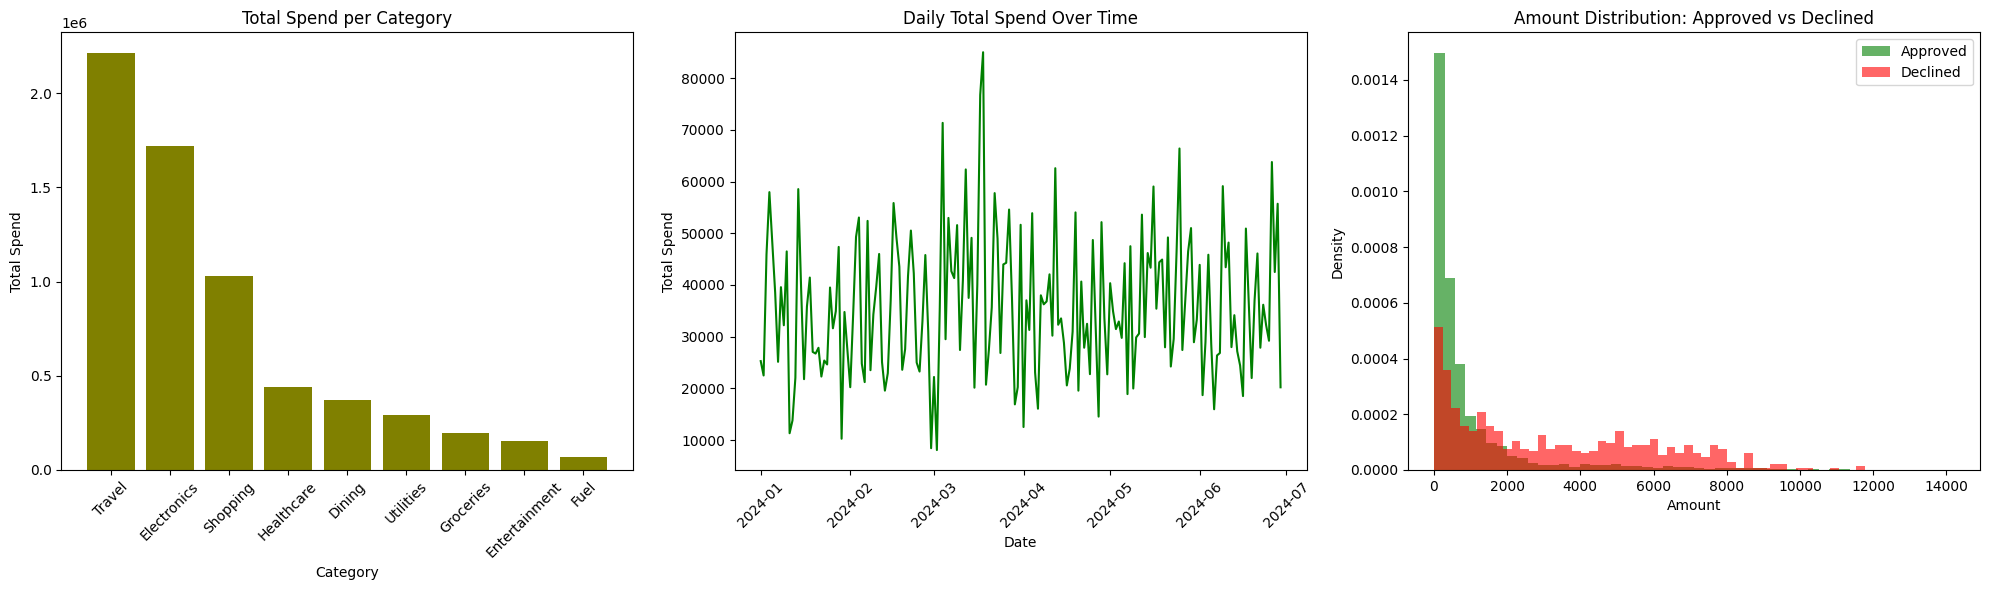

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Bar chart — Total spend per category
category_spend = df.groupby('category')['amount'].sum().sort_values(ascending=False)
axes[0].bar(category_spend.index, category_spend.values,color='olive')
axes[0].set_title('Total Spend per Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Spend')
axes[0].tick_params(axis='x', rotation=45)

# 2. Line chart — Daily total spend over time
df['date'] = df['datetime'].dt.date
daily_spend = df.groupby('date')['amount'].sum()
axes[1].plot(daily_spend.index, daily_spend.values,color='green' )
axes[1].set_title('Daily Total Spend Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Spend')
axes[1].tick_params(axis='x', rotation=45)

# 3. Histogram — Distribution of `amount` for approved vs declined transactions overlaid
approved_amounts = df[df['status'] == 'approved']['amount']
declined_amounts = df[df['status'] == 'declined']['amount']

axes[2].hist(approved_amounts, bins=50, alpha=0.6, label='Approved', color='green', density=True)
axes[2].hist(declined_amounts, bins=50, alpha=0.6, label='Declined', color='red', density=True)
axes[2].set_title('Amount Distribution: Approved vs Declined')
axes[2].set_xlabel('Amount')
axes[2].set_ylabel('Density')
axes[2].legend()

fig.tight_layout()
plt.show()

---
## Q7 — Bonus `[30 pts]`

> This question is intentionally hard. Not compulsory.

**SmartSwipe Velocity Fraud Detector**

A transaction is part of a **velocity fraud event** if a single `user_id` has **≥ 3 transactions within any rolling 1-hour window**.

Date and Time are available in the CSV.

Tasks:

1. Write a function `flag_velocity_fraud(df, window='1h', min_txns=3)` that returns a boolean Series aligned to `df.index` — `True` if the transaction falls inside a fraud window for that user.
   - Must handle per-user sorted datetime correctly.
   - No row-wise Python loops over the full DataFrame.
2. Add column `velocity_fraud` using your function.
3. Compare flagged vs normal users on: avg spend, decline rate, top categories. Print a clean summary table.
4. Plot a **timeline scatter** (x = datetime, y = user_id, colour = velocity_fraud). Limit to 20 users for readability.
